In [1]:
pip install porespy

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.7/304.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.9/23.9 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 23.4 MB/s eta 0:00:00
  Created wheel for docrep: filename=docrep-0.3.2-py3-none-any.whl size=19876 sha256=748a1147bc50cb86221854f0e333102aaf6bdd94b2b709ecd879ae141239eac6
  Stored in directory: /root/.cache/pip/wheels/c3/64/48/03c38d8d906159eaa210b3c548fdb590eb3e2a4a5745ae2172

In [2]:
import porespy as ps
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import imageio

from google.colab import files
# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200,200], porosity=0.16, blobiness=2)
im

ERROR:openpnm:PARDISO solver not installed, run `pip install pypardiso`. Otherwise, simulations will be slow. Apple M chips not supported.


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True],
       [False, False, False, ...,  True,  True,  True]])

## Loading a real data

In [3]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [4]:
#im_or = cv2.imread("PirabasB_2 - Copy.tif")
im_or = im

In [5]:
im_or.shape, im_or.dtype

((200, 200), dtype('bool'))

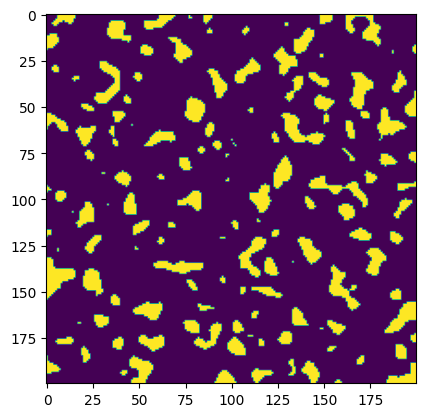

In [6]:
plt.imshow(im_or)

## With a sinthetic data

In [575]:
import numpy as np
import os
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

im_or = cv2.imread("porous_material (1).tiff")

In [576]:
im_or.shape


(200, 200, 3)

In [577]:
im_or = im_or[:,:,0]

In [578]:
im_or[:50,:50]

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

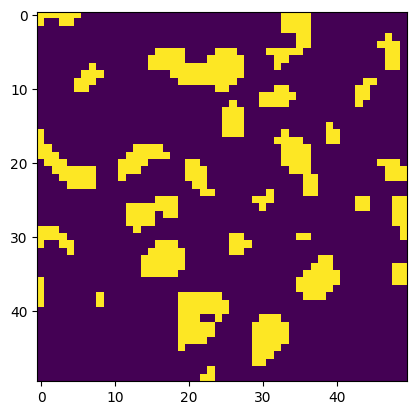

In [579]:
plt.imshow(im_or[:50,:50])

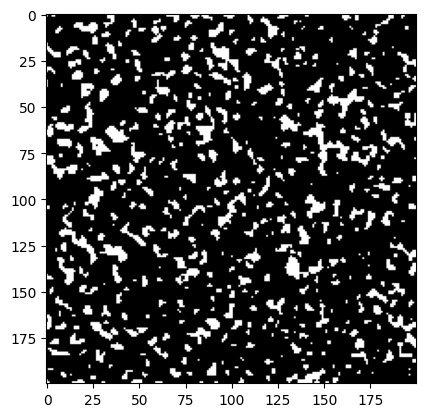

In [580]:
# In this version the pore is represented by the nubmer 1 (white mask/without cmap gray, is the green mask)
plt.imshow(im_or, cmap="gray")

## Processing

In [581]:
im_or = im_or[:, :, 0]

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [582]:
im_or.shape, im_or.dtype

((200, 200), dtype('uint8'))

In [583]:
# # Dividindo a imagem em 4 quadrantes
# height, width = im_or.shape
# half_height, half_width = height // 2, width // 2

# # Quadrantes
# top_left = im_or[:half_height, :half_width]
# top_right = im_or[:half_height, half_width:]
# bottom_left = im_or[half_height:, :half_width]
# bottom_right = im_or[half_height:, half_width:]

# # Verificando as formas dos quadrantes
# print("Top Left Shape:", top_left.shape)
# print("Top Right Shape:", top_right.shape)
# print("Bottom Left Shape:", bottom_left.shape)
# print("Bottom Right Shape:", bottom_right.shape)

In [584]:
##im = bottom_right # A great result

In [585]:
##im = bottom_left # A great result(runing)

In [586]:
##im = top_left # A great result

In [587]:
##im = top_right

In [588]:
##im.min(), im.max()

In [589]:
##im = (im - im.min())/ (im.max() - im.min())

In [590]:
##im.max(), im.min(), im.shape

In [591]:
im = im_or

In [592]:
im.dtype

dtype('uint8')

In [593]:
im = im.astype("uint8")

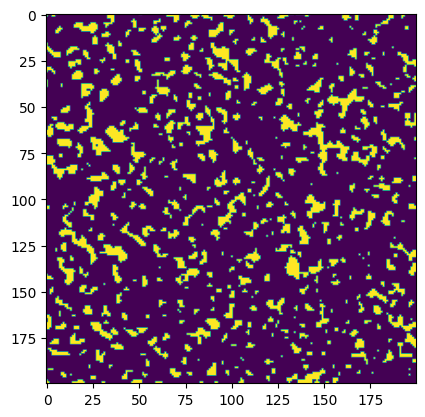

In [594]:
plt.imshow(im)
plt.show()

In [595]:
# Set the pore to be the value 1 # foreground
# This function is to create the binary image to the recognition process work
def create_binary_adjust_1(img):
    import cv2
    # Convert the image to grayscale
    #gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 25 # The ideal value to the sample pirabas 2
    thresold_value = 0
    max_value = 1
    #ret, binary = cv2.threshold(img, thresold_value, max_value, cv2.THRESH_BINARY_INV) # use this to pirabas 2
    ret, binary = cv2.threshold(img, thresold_value, max_value, cv2.THRESH_BINARY)
    return binary
# That's my case

In [596]:
binary_image = create_binary_adjust_1(im)

# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [597]:
binary_image.shape, binary_image.min(), binary_image.max()

((200, 200), 0, 1)

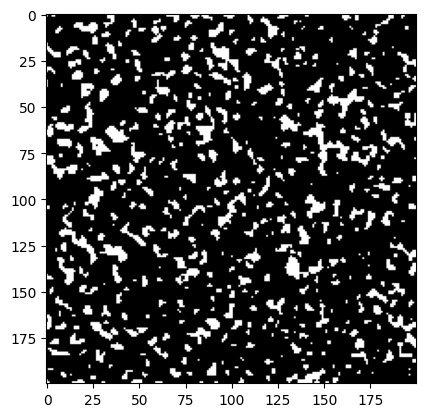

In [598]:
plt.imshow(binary_image, cmap='gray')

In [599]:
num_labels, labeled_image.shape

(525, (200, 200))

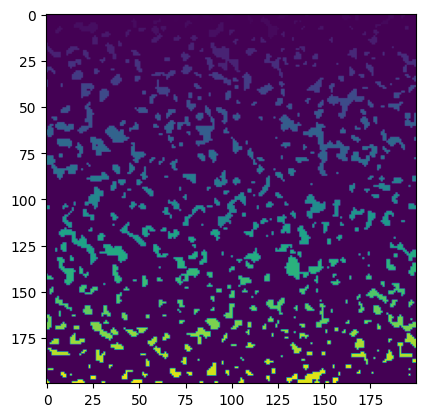

In [600]:
plt.imshow(labeled_image)

## save the segmented regions

In [601]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 265


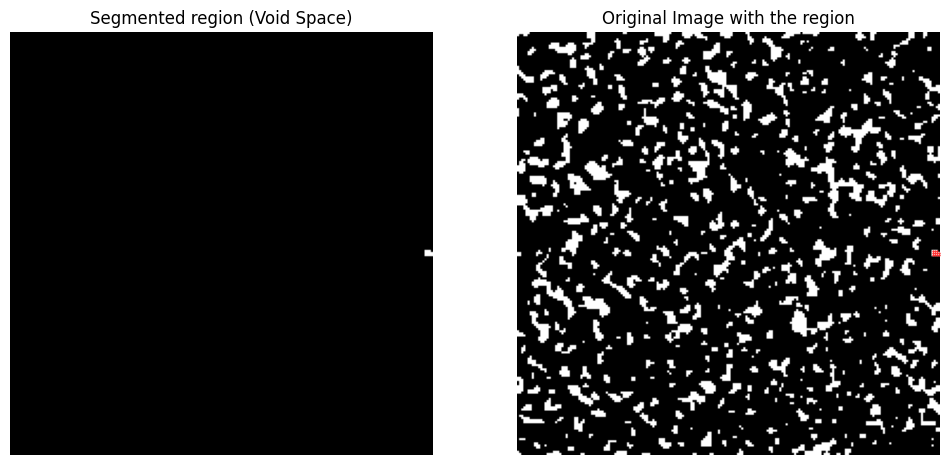

In [602]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [603]:
# The number of pixels to consider a pore

pore_number = 36 # This is the ideal cluster to the shape (384, 512) pirabasb_2

In [604]:
pore_number

36

In [605]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours, label, regionprops

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers

def calculate_aspect_ratios(contornos_por_cluster):
    aspect_ratios = []
    for contornos in contornos_por_cluster:
        for contorno in contornos:
            if len(contorno) < 5:
                continue
            # Encontrar as propriedades da região contornada
            x_min, y_min = np.min(contorno, axis=0)
            x_max, y_max = np.max(contorno, axis=0)
            major_axis_length = y_max - y_min
            minor_axis_length = x_max - x_min
            # Calcular a razão de aspecto
            if major_axis_length > 0:  # Evitar divisão por zero
                aspect_ratio = minor_axis_length / major_axis_length
            else:
                aspect_ratio = 0
            aspect_ratios.append(aspect_ratio)
    return aspect_ratios






#
# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
#areas_cluster_kmeans = []
#contour_per_cluster = []
ratio_of_aspect_cluster_kmeans = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)

    # Calcular as razões de aspecto dos clusters
    #aspect_ratios_kmeans = calculate_aspect_ratios(contornos_por_cluster)
    # ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)

    # Calcular as áreas dos clusters
    #areas_kmeans = calculate_areas(clustered_region_kmeans)
    #areas_cluster_kmeans.append(areas_kmeans)

    # Armazenar os contornos dos clusters
    #contour_per_cluster.append(contornos_por_cluster)

# # Exemplo de uso dos resultados
# for i, aspect_ratios in enumerate(ratio_of_aspect_cluster_kmeans):
#     print(f'Região {i+1}: Razões de aspecto dos clusters = {aspect_ratios}')

C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when

In [606]:
len(resultados_kmeans)

525

In [607]:
resultados_kmeans[ind_show].shape

(200, 200)

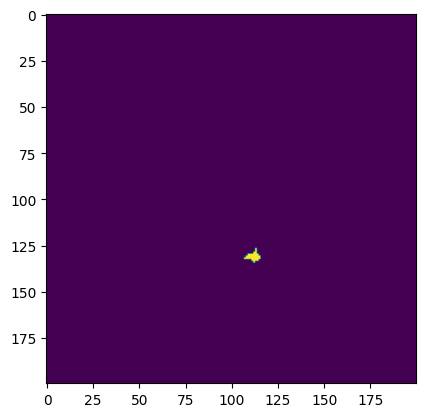

In [608]:
import random
ind_show = random.randint(0, len(resultados_kmeans))
plt.imshow(resultados_kmeans[ind_show])

In [609]:
# Check the values into the image
resultados_kmeans[ind_show].min(), resultados_kmeans[ind_show].max()

(0, 1)

In [610]:
resultados_kmeans = np.array(resultados_kmeans)

In [611]:
# Let's save each cluster in a separate data
print(ind_show)

323


In [612]:
list_cluster_per_regions = []
for i in range(1, resultados_kmeans[ind_show].max()+1):
  # Create a new tensor where values not equal to 0 or 1 are set to 0
  temp_tensor = np.where((resultados_kmeans[ind_show] == 0) | (resultados_kmeans[ind_show] == i), resultados_kmeans[ind_show], 0)
  list_cluster_per_regions.append(temp_tensor)

In [613]:
# convert to the numpy array
list_cluster_per_regions = np.array(list_cluster_per_regions)

The shape: (1, 200, 200)
The pore number 0


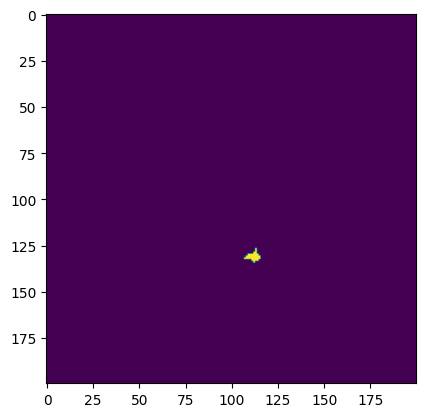

In [614]:
# Check the shape and the separated clusterized regions
import random
index_show_clusters = random.randint(0,len(list_cluster_per_regions)-1)
print("The shape:", list_cluster_per_regions.shape)
print("The pore number", index_show_clusters)
plt.imshow(list_cluster_per_regions[index_show_clusters])

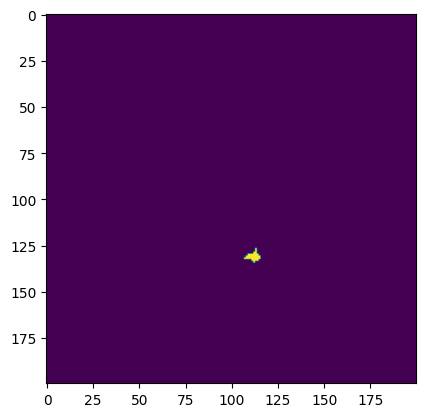

In [615]:
plt.imshow(resultados_kmeans[ind_show])

In [616]:
resultados_kmeans[0].shape

(200, 200)

## Create the globals to each clusterized region from resultados_kmeans

In [617]:
# for ii in range(0,len(resultados_kmeans)):
#   list_cluster_per_regions = []
#   for i in range(1, resultados_kmeans[ii].max()+1):
#     # Create a new tensor where values not equal to 0 or 1 are set to 0
#     temp_tensor = np.where((resultados_kmeans[ind_show] == 0) | (resultados_kmeans[ii] == i), resultados_kmeans[ii], 0)
#     list_cluster_per_regions.append(temp_tensor)
#   list_cluster_per_regions = np.array(list_cluster_per_regions)
#   tensor_name = f"tensor_{ii}"
#   globals()[tensor_name] = list_cluster_per_regions

In [618]:
# for ii in range(len(resultados_kmeans)):
#     list_cluster_per_regions = []
#     contornos_por_cluster = []

#     for i in range(1, resultados_kmeans[ii].max() + 1):
#         # Create a new tensor where values not equal to 0 or 1 are set to 0
#         temp_tensor = np.where((resultados_kmeans[ii] == 0) | (resultados_kmeans[ii] == i), resultados_kmeans[ii], 0)
#         list_cluster_per_regions.append(temp_tensor)

#         # Convert the tensor to uint8 type for contour finding
#         temp_tensor_uint8 = (temp_tensor * 255).astype(np.uint8)

#         # Find contours for the current region
#         contours, _ = cv2.findContours(temp_tensor_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
#         contornos_por_cluster.append(contours)

#     list_cluster_per_regions = np.array(list_cluster_per_regions)
#     tensor_name = f"tensor_{ii}"
#     globals()[tensor_name] = list_cluster_per_regions

#     # Save contours for the current cluster
#     contornos_name = f"contornos_{ii}"
#     globals()[contornos_name] = contornos_por_cluster

In [619]:
import numpy as np
import cv2

# Função para calcular a razão de aspecto
def calculate_aspect_ratios(contornos_por_cluster):
    aspect_ratios = []
    for contornos in contornos_por_cluster:
        for contorno in contornos:
            if len(contorno) < 5: # The minimum to calculate the ratio of aspect is n points in contornos > 5
                continue
            # Encontrar as propriedades da região contornada
            x_min, y_min = np.min(contorno, axis=0)[0]
            x_max, y_max = np.max(contorno, axis=0)[0]
            major_axis_length = y_max - y_min
            minor_axis_length = x_max - x_min
            # Calcular a razão de aspecto
            if major_axis_length > 0:  # Evitar divisão por zero
                aspect_ratio = minor_axis_length / major_axis_length
            else:
                aspect_ratio = 0
            aspect_ratios.append(aspect_ratio)
    return aspect_ratios

# Processar clusters e calcular contornos e razões de aspecto
for ii in range(len(resultados_kmeans)):
    list_cluster_per_regions = []
    contornos_por_cluster = []

    for i in range(1, resultados_kmeans[ii].max() + 1):
        # Criar um novo tensor onde valores diferentes de 0 ou 1 são definidos como 0
        temp_tensor = np.where((resultados_kmeans[ii] == 0) | (resultados_kmeans[ii] == i), resultados_kmeans[ii], 0)
        list_cluster_per_regions.append(temp_tensor)

        # Converter o tensor para o tipo uint8 para encontrar contornos
        temp_tensor_uint8 = (temp_tensor * 255).astype(np.uint8)

        # Encontrar contornos para a região atual
        contours, _ = cv2.findContours(temp_tensor_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        contornos_por_cluster.append(contours)

    list_cluster_per_regions = np.array(list_cluster_per_regions)
    tensor_name = f"tensor_{ii}"
    globals()[tensor_name] = list_cluster_per_regions

    # Salvar contornos para o cluster atual
    contornos_name = f"contornos_{ii}"
    globals()[contornos_name] = contornos_por_cluster

    # Calcular razões de aspecto para os contornos do cluster atual
    aspect_ratios = calculate_aspect_ratios(contornos_por_cluster)
    aspect_ratios_name = f"aspect_ratios_{ii}"
    globals()[aspect_ratios_name] = aspect_ratios

# Exemplo de como acessar as razões de aspecto calculadas
#for ii in range(len(resultados_kmeans)):
#    aspect_ratios_name = f"aspect_ratios_{ii}"
#    print(f"Razões de aspecto para o cluster {ii}: {globals()[aspect_ratios_name]}")


In [620]:
num_tensors = len(resultados_kmeans)

In [621]:
len(resultados_kmeans)

525

In [622]:
for i in range(1, num_tensors):
    tensor_name = f"tensor_{i}"
    
    #print(f"{tensor_name}:\n{globals()[tensor_name]}\n")

In [623]:
tensor_105.shape, resultados_kmeans[105].max(), resultados_kmeans[105].shape

((1, 200, 200), 1, (200, 200))

In [624]:
aspect_ratios_105

[1.0]

In [625]:
len(contornos_105)

1

The shape: (1, 200, 200)
The pore number 0
The aspect ratio 1.0


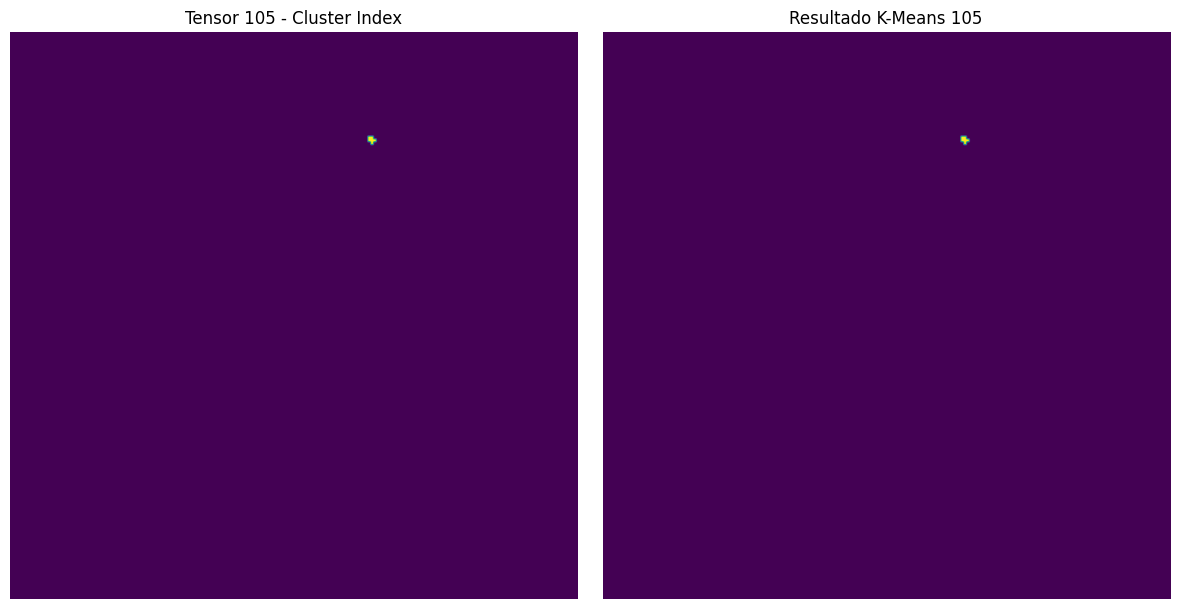

In [626]:
# Check the shape and the separated clusterized regions
import random
index_show_clusters = random.randint(0,len(tensor_105)-1)
print("The shape:", tensor_105.shape)
print("The pore number", index_show_clusters)
print("The aspect ratio", aspect_ratios_105[index_show_clusters])
# Crie uma figura e dois subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot da primeira imagem
axes[0].imshow(tensor_105[index_show_clusters])
axes[0].set_title('Tensor 105 - Cluster Index')
axes[0].axis('off')  # Opcional, para ocultar os eixos

# Plot da segunda imagem
axes[1].imshow(resultados_kmeans[105])
axes[1].set_title('Resultado K-Means 105')
axes[1].axis('off')  # Opcional, para ocultar os eixos

# Exibir a figura
plt.tight_layout()
plt.show()

In [627]:
import random 
index_region_with_cluster = random.randint(0,len(resultados_kmeans)-1)
index_region_with_cluster

354

## Generate the train data and build the cnn model to classify the pores

In [83]:
# generate the trained data
import numpy as np

# Define the size of the vector
size = 1000000  # Example size of the vector

# Generate the vector with values between 0 and 2
feature_aspect_ratio = np.random.uniform(low=0, high=2, size=size)

In [84]:
len(feature_aspect_ratio)

1000000

In [85]:
type_pore = []
for i in range(0,len(feature_aspect_ratio)):
    if feature_aspect_ratio[i] < 1:
        type_pore_temp = 1
    elif feature_aspect_ratio[i] == 1:
        type_pore_temp = 2
    elif feature_aspect_ratio[i] > 1:
        type_pore_temp = 3
    type_pore.append(type_pore_temp)

In [86]:
len(type_pore), len(feature_aspect_ratio)

(1000000, 1000000)

In [87]:
feature_aspect_ratio.max(), feature_aspect_ratio.min()

(1.9999966752792278, 2.1485354195771578e-06)

In [76]:
# Let's normalize the data to the cnn model
feature_aspect_ratio_normalized = (feature_aspect_ratio - feature_aspect_ratio.min())/(feature_aspect_ratio.max() - feature_aspect_ratio.min())

In [88]:
feature_aspect_ratio_normalized.max(), feature_aspect_ratio_normalized.min()

(1.0, 0.0)

In [89]:
# Checking if the data to train the model is correct
type_pore[1], feature_aspect_ratio[1]

(1, 0.48925671495374323)

In [90]:
dictionary_pores_type = {1:"Flattened", 2:"Spherical or nearly spherical", 3:"Elongated or stretched"}

In [91]:
from sklearn.model_selection import train_test_split
# Separate the data into train and test
x_train, x_test, y_train, y_test = train_test_split(feature_aspect_ratio, type_pore, test_size =0.3, shuffle=True, random_state = 42)

In [92]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [93]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((700000,), (300000,), (700000,), (300000,))

In [94]:
# Checking the dtype
y_train.dtype, y_test.dtype

(dtype('int32'), dtype('int32'))

In [95]:
y_train = y_train.astype("uint8")
y_test = y_test.astype("uint8")

In [96]:
# Convert the dimension to be compatible with the cnn from the shape (n,) to (n,1), where 1 is the number of features
x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

In [97]:
x_train.shape, x_test.shape

((700000, 1), (300000, 1))

In [98]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create the CNN model
model = Sequential([
    Conv1D(8, kernel_size=1, activation='relu', input_shape=(1, 1)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(lr=0.01), loss='mean_squared_error')

C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [99]:
# Train the model
model.fit(x_train, y_train, epochs=20)

Epoch 1/20
21875/21875 [==============================] - 50s 2ms/step - loss: 0.0648
Epoch 2/20
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0133
Epoch 3/20
21875/21875 [==============================] - 46s 2ms/step - loss: 0.0122
Epoch 4/20
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0113
Epoch 5/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0112
Epoch 6/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0108
Epoch 7/20
21875/21875 [==============================] - 46s 2ms/step - loss: 0.0104
Epoch 8/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0101
Epoch 9/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0097
Epoch 10/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0096
Epoch 11/20
21875/21875 [==============================] - 44s 2ms/step - loss: 0.0094
Epoch 12/20
21875/21875 [===========================

In [100]:
x_test.shape

(300000, 1)

In [101]:
# Evaluate the model
accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy}")

9375/9375 [==============================] - 13s 1ms/step - loss: 0.0040
Test accuracy: 0.003956467378884554


In [102]:
y_pred_test = model.predict(x_test)

9375/9375 [==============================] - 8s 865us/step


In [103]:
y_pred_test.dtype

dtype('float32')

In [104]:
y_pred_test[0], y_test[0]

(array([3.0394282], dtype=float32), 3)

In [105]:
len(ratio_of_aspect_cluster_kmeans)

0

In [ ]:
number_of_pores_kmeans = np.array(number_of_pores_kmeans)

## Organize the data to classify with the cnn model

In [628]:
dictionary_pores_type = {1:"Flattened", 2:"Spherical or nearly spherical", 3:"Elongated or stretched"}

The shape: (1, 200, 200)
The pore number 0
The aspect ratio 1.0


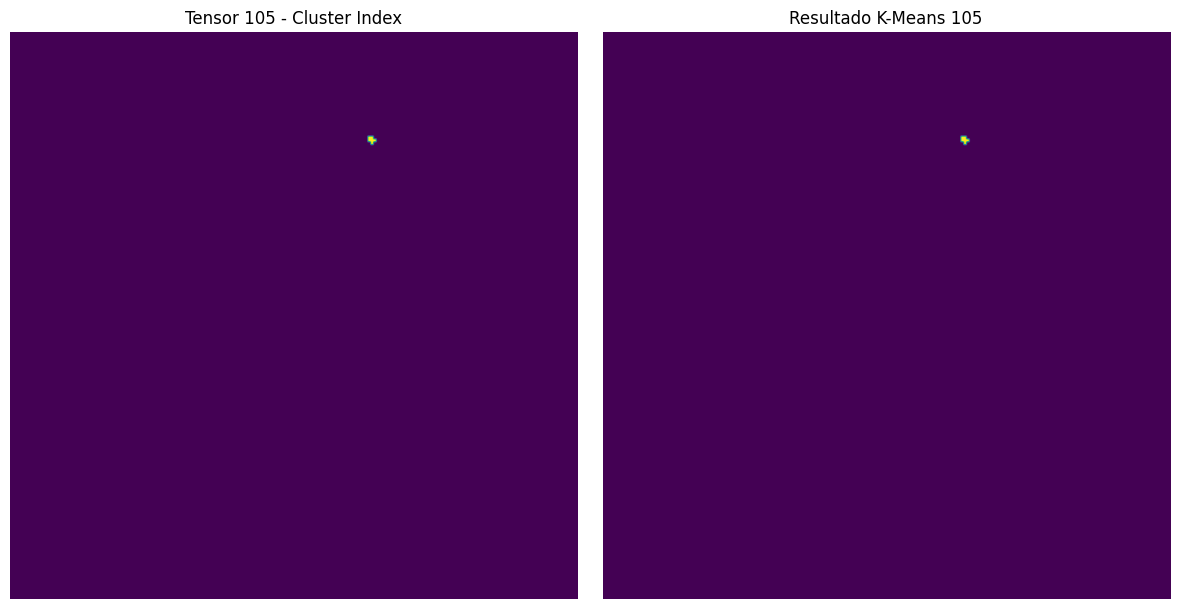

In [629]:
# Check the shape and the separated clusterized regions
import random
index_show_clusters = random.randint(0,len(tensor_105)-1)
print("The shape:", tensor_105.shape)
print("The pore number", index_show_clusters)
print("The aspect ratio", aspect_ratios_105[index_show_clusters])
# Crie uma figura e dois subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot da primeira imagem
axes[0].imshow(tensor_105[index_show_clusters])
axes[0].set_title('Tensor 105 - Cluster Index')
axes[0].axis('off')  # Opcional, para ocultar os eixos

# Plot da segunda imagem
axes[1].imshow(resultados_kmeans[105])
axes[1].set_title('Resultado K-Means 105')
axes[1].axis('off')  # Opcional, para ocultar os eixos

# Exibir a figura
plt.tight_layout()
plt.show()

In [630]:
import random 
index_region_with_cluster = random.randint(0,len(resultados_kmeans)-1)
index_region_with_cluster

407

## Generate the train data and build the cnn model to classify the pores

In [731]:
# generate the trained data
import numpy as np

# Define the size of the vector
size = 1000000  # Example size of the vector

# Generate the vector with values between 0 and 2
feature_aspect_ratio = np.random.uniform(low=0, high=10, size=size)

In [732]:
len(feature_aspect_ratio)

1000000

In [733]:
type_pore = []
for i in range(0,len(feature_aspect_ratio)):
    if feature_aspect_ratio[i] < 1:
        type_pore_temp = 1
    elif feature_aspect_ratio[i] == 1:
        type_pore_temp = 2
    elif feature_aspect_ratio[i] > 1:
        type_pore_temp = 3
    type_pore.append(type_pore_temp)

In [734]:
len(type_pore), len(feature_aspect_ratio)

(1000000, 1000000)

In [735]:
feature_aspect_ratio.max(), feature_aspect_ratio.min()

(9.999996488337397, 1.6811969429930684e-05)

In [736]:
# Let's normalize the data to the cnn model
feature_aspect_ratio_normalized = (feature_aspect_ratio - feature_aspect_ratio.min())/(feature_aspect_ratio.max() - feature_aspect_ratio.min())

In [737]:
feature_aspect_ratio_normalized.max(), feature_aspect_ratio_normalized.min()

(1.0, 0.0)

In [738]:
# Checking if the data to train the model is correct
type_pore[1], feature_aspect_ratio[1]

(3, 7.16344076227408)

In [739]:
dictionary_pores_type = {1:"Flattened", 2:"Spherical or nearly spherical", 3:"Elongated or stretched"}

In [740]:
from sklearn.model_selection import train_test_split
# Separate the data into train and test
x_train, x_test, y_train, y_test = train_test_split(feature_aspect_ratio, type_pore, test_size =0.3, shuffle=True, random_state = 42)

In [741]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [742]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((700000,), (300000,), (700000,), (300000,))

In [743]:
# Checking the dtype
y_train.dtype, y_test.dtype

(dtype('int32'), dtype('int32'))

In [744]:
y_train = y_train.astype("uint8")
y_test = y_test.astype("uint8")

In [745]:
# Convert the dimension to be compatible with the cnn from the shape (n,) to (n,1), where 1 is the number of features
x_train = x_train.reshape(-1,1)
x_test = x_test.reshape(-1,1)

In [746]:
x_train.shape, x_test.shape

((700000, 1), (300000, 1))

In [747]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Create the CNN model
model = Sequential([
    Conv1D(8, kernel_size=1, activation='relu', input_shape=(1, 1)),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer=Adam(lr=0.01), loss='mean_squared_error')

C:\Users\CometLake_05\anaconda3\envs\GPU-test3\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [748]:
# Train the model
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0159
Epoch 2/5
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0054
Epoch 3/5
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0041
Epoch 4/5
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0036
Epoch 5/5
21875/21875 [==============================] - 45s 2ms/step - loss: 0.0033


In [749]:
x_test.shape

(300000, 1)

In [750]:
# Evaluate the model
accuracy = model.evaluate(x_test, y_test)
print(f"Test accuracy: {accuracy}")

9375/9375 [==============================] - 12s 1ms/step - loss: 0.0021
Test accuracy: 0.002072463510558009


In [751]:
y_pred_test = model.predict(x_test)

9375/9375 [==============================] - 7s 774us/step


In [752]:
y_pred_test.dtype

dtype('float32')

In [753]:
y_pred_test[0], y_test[0]

(array([3.0028758], dtype=float32), 3)

In [754]:
len(ratio_of_aspect_cluster_kmeans)

0

In [755]:
number_of_pores_kmeans = np.array(number_of_pores_kmeans)

## Organize the data to classify with the cnn model

In [631]:
dictionary_pores_type = {1:"Flattened", 2:"Spherical or nearly Spherical", 3:"Elongated"}

In [632]:
# Checking the cluster regions in resultados_kmeans that has more than 1 clusters.
list_of_regions_index_i = []
for i in range(len(resultados_kmeans)):
    if resultados_kmeans[i].max() > 1:
        temp = i
        list_of_regions_index_i.append(temp)

In [633]:
list_of_regions_index_i

[52, 118, 155, 164, 198, 249, 301, 318, 334]

In [634]:
len(list_of_regions_index_i)

9

In [658]:
import random
rand_region_i = random.randint(0,len(list_of_regions_index_i)-1)
rand_region = list_of_regions_index_i[rand_region_i]
rand_region

164

In [659]:
tensor_name = f"tensor_{rand_region}"
#globals()[tensor_name] 

# Salvar contornos para o cluster atual
contornos_name = f"contornos_{rand_region}"
#globals()[contornos_name] 

aspect_ratios_name = f"aspect_ratios_{rand_region}"
#globals()[aspect_ratios_name]

In [660]:
globals()[aspect_ratios_name], resultados_kmeans[rand_region].max()

([0.8571428571428571, 1.1, 0.5555555555555556, 0.5, 2.6666666666666665], 5)

In [661]:
globals()[aspect_ratios_name] = np.array(globals()[aspect_ratios_name])

In [662]:
# classify with the cnn model into Flattened, Spherical or Elongated

In [663]:
vect_asp = globals()[aspect_ratios_name].reshape(-1,1)

In [664]:
vect_asp.shape

(5, 1)

In [665]:
y_pred_classify_pores = model.predict(vect_asp)

1/1 [==============================] - 0s 14ms/step


In [666]:
y_pred_classify_pores

array([[1.0056969],
       [3.04359  ],
       [1.0056969],
       [1.0056969],
       [3.0335803]], dtype=float32)

In [667]:
#y_pred_classify_pores = y_pred_classify_pores.astype("uint8")

In [668]:
key = y_pred_classify_pores[0]
key = int(key)

In [669]:
key

1

In [670]:
dictionary_pores_type[key]

'Flattened'

In [803]:
# Check the shape and the separated clusterized regions
import random
index_show_clusters = random.randint(0,len(globals()[tensor_name])-1)
print("The shape:", globals()[tensor_name].shape)
print("The pore number", index_show_clusters)
print("The aspect ratio", globals()[aspect_ratios_name][index_show_clusters])
key = y_pred_classify_pores[index_show_clusters]
key = int(key)
print("The cnn classify the pore as:", dictionary_pores_type[key])
# Crie uma figura e dois subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot da primeira imagem
axes[0].imshow(globals()[tensor_name][index_show_clusters])
axes[0].set_title('Clusterized region and his group')
axes[0].axis('off')  # Opcional, para ocultar os eixos

# Plot da segunda imagem
axes[1].imshow(resultados_kmeans[rand_region])
axes[1].set_title('Resultado K-Means')
axes[1].axis('off')  # Opcional, para ocultar os eixos

# Exibir a figura
plt.tight_layout()
plt.show()

The shape: (5, 200, 200)
The pore number 3


IndexError: list index out of range

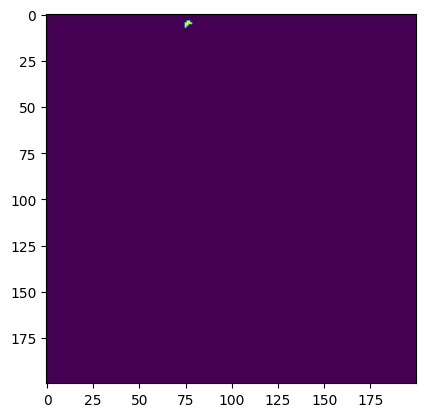

In [672]:
plt.imshow(resultados_kmeans[16])

In [650]:
globals()[contornos_name] # Remind that the number of points in the contourn is supposed to be great than 5
# You can adjust this value as you prefer....

[(array([[[132, 131]],
  
         [[131, 132]],
  
         [[131, 134]],
  
         [[130, 135]],
  
         [[130, 136]],
  
         [[129, 137]],
  
         [[130, 138]],
  
         [[130, 140]],
  
         [[131, 140]],
  
         [[133, 138]],
  
         [[134, 138]],
  
         [[136, 136]],
  
         [[136, 135]],
  
         [[135, 134]],
  
         [[135, 133]],
  
         [[134, 132]],
  
         [[133, 132]]], dtype=int32),),
 (array([[[136, 137]],
  
         [[134, 139]],
  
         [[133, 139]],
  
         [[131, 141]],
  
         [[133, 141]],
  
         [[135, 143]],
  
         [[136, 143]],
  
         [[136, 141]],
  
         [[137, 140]],
  
         [[138, 140]],
  
         [[139, 141]],
  
         [[139, 142]],
  
         [[140, 142]],
  
         [[141, 141]],
  
         [[141, 140]],
  
         [[137, 140]],
  
         [[136, 139]]], dtype=int32),)]

## Estimating the percentage of each type of pore:1 : Flattened", 2:"Spherical or nearly Spherical", 3:"Elongated
Flattened (The ratio of aspect < 1)
Spherical or nearly Spherical (The ratio of aspect = 1)
Elongated (The ratio of aspect > 1)

In [685]:
len(resultados_kmeans)

525

In [ ]:
# Checking the value 

In [715]:
list_total_aspect_ratio = []
for ii in range(len(resultados_kmeans)):
    aspect_ratios_name = f"aspect_ratios_{ii}"
    for jj in range(len(globals()[aspect_ratios_name])):
        temp_asp_rat = globals()[aspect_ratios_name][jj]
        list_total_aspect_ratio.append(temp_asp_rat)

In [716]:
resultados_kmeans[0].max(), resultados_kmeans[1].max(), resultados_kmeans[2].max()

(1, 1, 1)

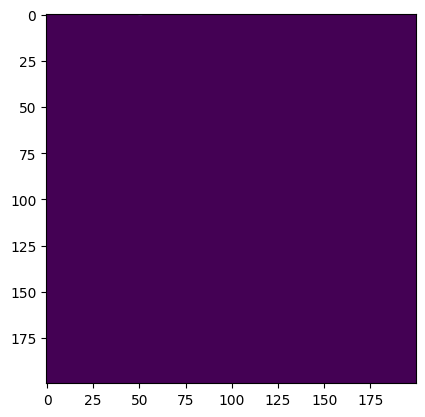

In [717]:
plt.imshow(resultados_kmeans[2])

In [805]:
len(list_total_aspect_ratio)

286

In [719]:
list_total_aspect_ratio = np.array(list_total_aspect_ratio)

In [720]:
list_total_aspect_ratio.shape

(286,)

In [721]:
list_total_aspect_ratio = list_total_aspect_ratio.reshape(-1,1)

In [722]:
list_total_aspect_ratio.shape

(286, 1)

In [723]:
list_total_aspect_ratio.max(), list_total_aspect_ratio.min()

(7.0, 0.2857142857142857)

In [756]:
y_classify_total = model.predict(list_total_aspect_ratio)

9/9 [==============================] - 0s 2ms/step


In [761]:
len(y_classify_total)

286

In [758]:
y_classify_total[0], list_total_aspect_ratio[0]

(array([3.0028758], dtype=float32), array([5.]))

In [765]:
len(y_classify_total)

286

In [779]:
y_classify_total.max(), round(y_classify_total.min())

(3.0028758, 1)

In [781]:
y_classify_total.shape

(286, 1)

In [788]:
y_classify_total = y_classify_total.reshape(-1,)

In [789]:
y_classify_total.shape

(286,)

In [790]:
# Calculate the number of element in each class
list_flattened_pores =[]
list_spherical_or_near_spherical_pores = []
list_elongated_pores = []
for i in range(len(y_classify_total)):
    temp_key = round(y_classify_total[i])
    if temp_key == 1:
        temp_flat = temp_key
        list_flattened_pores.append(temp_flat)
    elif temp_key == 2:
        temp_spherical_or_near_spherical = temp_key
        list_spherical_or_near_spherical_pores.append(temp_spherical_or_near_spherical)
    elif temp_key == 3:
        temp_elongated = temp_key
        list_elongated_pores.append(temp_elongated)

In [791]:
len(list_flattened_pores), len(list_spherical_or_near_spherical_pores), len(list_elongated_pores)

(98, 72, 116)

In [794]:
# Calcualte the percentage
perc_flattened_pores = (len(list_flattened_pores) * 100)/286
perc_spherical_or_near_spherical_pores = (len(list_spherical_or_near_spherical_pores)*100)/286
perc_elongated_pores = (len(list_elongated_pores)*100)/286

In [795]:
perc_flattened_pores, perc_spherical_or_near_spherical_pores, perc_elongated_pores

(34.26573426573427, 25.174825174825173, 40.55944055944056)

In [797]:
perc_flattened_pores+perc_spherical_or_near_spherical_pores+perc_elongated_pores == 100.0

True

The percentage of flattened pores= 34.2657 %
The percentage of spherical or near spherical pores= 25.1748 %
The percentage of elongated pores = 40.5594 %


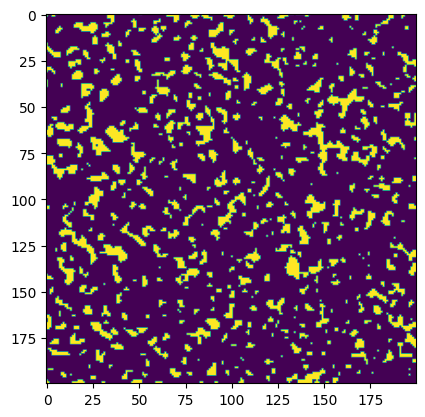

In [802]:
print("The percentage of flattened pores=",round(perc_flattened_pores,4) ,"%")
print("The percentage of spherical or near spherical pores=",round(perc_spherical_or_near_spherical_pores,4), "%")
print("The percentage of elongated pores =", round(perc_elongated_pores,4), "%")
plt.imshow(im_or)

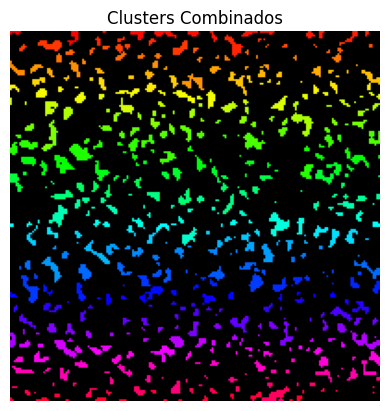

In [801]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Supondo que resultados_kmeans seja uma lista de arrays, onde cada array representa um cluster
# E cada array tem a mesma forma que a imagem original

# Vamos supor que a imagem original tem a forma (height, width)
image_shape = resultados_kmeans[0].shape

# Cria uma imagem vazia para plotar os clusters com três canais (para RGB)
combined_image = np.zeros((*image_shape, 3), dtype=np.uint8)

# Cria uma paleta de cores para os clusters
colors = plt.cm.get_cmap('hsv', len(resultados_kmeans))

# Plotar cada cluster com uma cor diferente
for i, cluster in enumerate(resultados_kmeans):
    # Obtém a cor e converte para formato RGB
    color = (np.array(colors(i)[:3]) * 255).astype(int)
    combined_image[cluster == 1] = color

# Exibir a imagem combinada
plt.imshow(combined_image)
plt.title('Clusters Combinados')
plt.axis('off')
plt.show()
